In [32]:
"""
Planned visualizations

1. Percent conversion from hospital stay to ICU stay, by gender, socioeconomic status?
2. Intensity of charting/leb events during hospital stay by gender and socioeconomic status
3. Pain medication administration by race and gender
4. Rate of mental health diagnoses by gender
5. Transfer rates by ICU unit

"""

# Import modules used throughout the notebook
import pandas as pd
import matplotlib.pyplot as plt

# Import tables used throughout the notebook
admissions = pd.read_csv('data/admissions.csv')
patients = pd.read_csv('data/patients.csv')
icustays = pd.read_csv('data/icustays.csv')
chartevents = pd.read_csv('data/chartevents.csv')
labevents = pd.read_csv('data/labevents.csv')
emar = pd.read_csv('data/emar.csv')
diagnoses_icd = pd.read_csv('data/diagnoses_icd.csv')
transfers = pd.read_csv('data/transfers.csv')

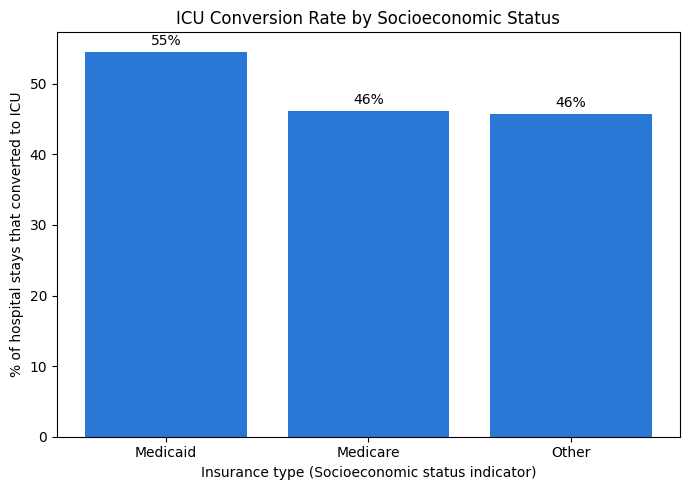

In [9]:
"""
1. Percent conversion from hospital stay to ICU stay, by gender, socioeconomic status

Columns needed:
----------------------
admissions.hadm_id 
admissions.subject_id
admissions.insurance

patients.subject_id
patients.gender

icustays.hadm_id
icustays.subject_id
icustays.stay_id

"""

# Add column for ICU conversion to admissions using set membership
icu_hadm_ids = set(icustays['hadm_id'])
admissions['went_to_icu'] = admissions['hadm_id'].isin(icu_hadm_ids)

# Get percent of conversion by insurance type
conversion_by_insurance = admissions.groupby('insurance')['went_to_icu'].mean() * 100
counts_by_insurance = admissions.groupby('insurance').size()

plt.figure(figsize=(7, 5))
bars = plt.bar(conversion_by_insurance.index, conversion_by_insurance.values, color='#2a78d6')

# label each bar with its percentage
for bar, pct in zip(bars, conversion_by_insurance.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f'{pct:.0f}%', ha='center')

plt.ylabel('% of hospital stays that converted to ICU')
plt.xlabel('Insurance type (Socioeconomic status indicator)')
plt.title('ICU Conversion Rate by Socioeconomic Status')
plt.tight_layout()
plt.show()

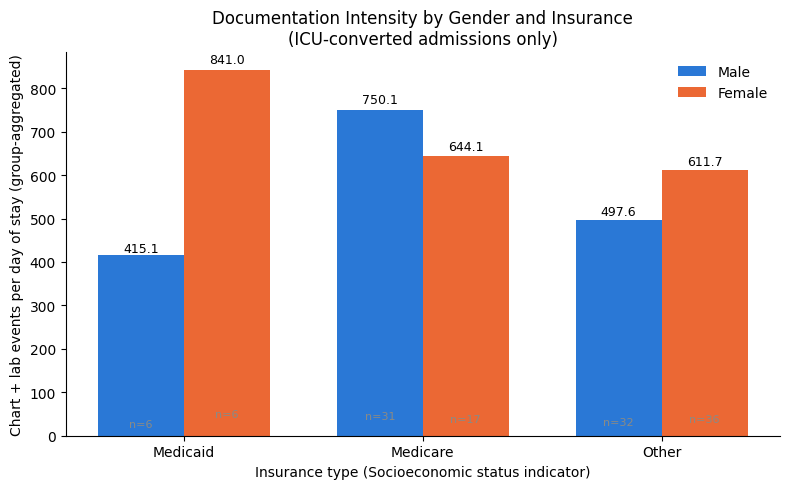

In [18]:
"""
2. Intensity of charting/leb events during hospital stay by gender and socioeconomic status

Columns needed:
-----------------------
admissions.hadm_id
admissions.subject_id
admissions.insurance
admissions.admittime
admissions.dischtime

patients.subject_id
patients.gender

chartevents.hadm_id
chartevents.subject_id
chartevents.charttime

labevents.hadm_id
labevents.subject_id
labevents.charttime
"""

# Add column for ICU conversion to admissions using set membership
icu_hadm_ids = set(icustays['hadm_id'])
admissions_icu = admissions[admissions['hadm_id'].isin(icu_hadm_ids)].copy()

# Add column for length of stay (in days)
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])

admissions_icu['los_days'] = (
    (admissions_icu['dischtime'] - admissions_icu['admittime'])
    .dt.total_seconds() / 86400
)

chart_counts = chartevents.groupby('hadm_id').size().rename('n_chartevents')
lab_counts = labevents.groupby('hadm_id').size().rename('n_labevents')

admissions_icu = admissions_icu.merge(chart_counts, on='hadm_id', how='left')
admissions_icu = admissions_icu.merge(lab_counts, on='hadm_id', how='left')

# Clean data - admissions with no events
admissions_icu[['n_chartevents', 'n_labevents']] = admissions_icu[['n_chartevents', 'n_labevents']].fillna(0)

# Total events per admission (per-admission LOS still kept for the group aggregation below)
admissions_icu['total_events'] = admissions_icu['n_chartevents'] + admissions_icu['n_labevents']

# Join on gender
admissions_icu = admissions_icu.merge(patients[['subject_id', 'gender']], on='subject_id', how='left')

# Aggregate per stay - this could cause skew from very short or long stays, may not be super robust
group_sums = (
    admissions_icu.groupby(['insurance', 'gender'])
    .agg(total_events=('total_events', 'sum'),
         total_los_days=('los_days', 'sum'),
         n=('hadm_id', 'count'))
    .reset_index()
)

group_sums['events_per_stay_day'] = group_sums['total_events'] / group_sums['total_los_days']

# Create bar chart and visualize
group_sums = group_sums.sort_values(['insurance', 'gender'])  # keep order consistent
pivot_vals = group_sums.pivot(index='insurance', columns='gender', values='events_per_stay_day')
pivot_n = group_sums.pivot(index='insurance', columns='gender', values='n')

COLOR_M = '#2a78d6'  # blue
COLOR_F = '#eb6834'  # orange

x = range(len(pivot_vals.index))
width = 0.36

fig, ax = plt.subplots(figsize=(8, 5))
bars_m = ax.bar([i - width/2 for i in x], pivot_vals['M'], width, label='Male', color=COLOR_M)
bars_f = ax.bar([i + width/2 for i in x], pivot_vals['F'], width, label='Female', color=COLOR_F)

# Label each bar with its value
for bars, gender in [(bars_m, 'M'), (bars_f, 'F')]:
    for bar, insurance in zip(bars, pivot_vals.index):
        val = pivot_vals.loc[insurance, gender]
        n = pivot_n.loc[insurance, gender]
        ax.text(bar.get_x() + bar.get_width()/2, val + val * 0.02, f'{val:.1f}',
                 ha='center', fontsize=9)
        ax.text(bar.get_x() + bar.get_width()/2, val * 0.05, f'n={n:.0f}',
                 ha='center', fontsize=8, color='#8a8a86')

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_vals.index)
ax.set_ylabel('Chart + lab events per day of stay (group-aggregated)')
ax.set_xlabel('Insurance type (Socioeconomic status indicator)')
ax.set_title('Documentation Intensity by Gender and Insurance\n(ICU-converted admissions only)')

ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

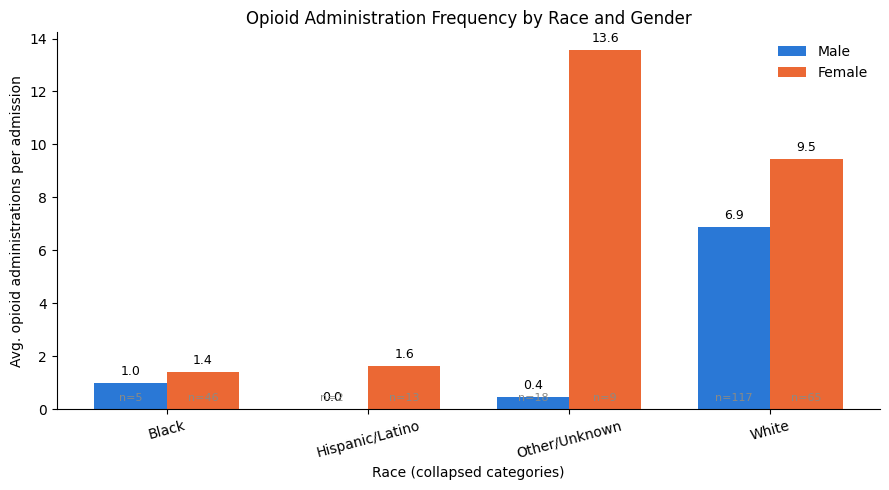

In [24]:
"""
3. Pain medication administration by race and gender

Columns needed:
-----------------------
admissions.hadm_id
admissions.subject_id
admissions.race

patients.subject_id
patients.gender

emar.hadm_id
emar.subject_id
emar.medication
emar.charttime
emar.event_txt
"""

import pandas as pd
import matplotlib.pyplot as plt

# Define the set of common opioid names to match against
opioid_names = {
    'morphine',
    'oxycodone',
    'fentanyl',
    'hydromorphone',
    'hydrocodone',
    'codeine',
    'tramadol',
    'methadone',
    'oxymorphone',
    'meperidine'
}

# Build one regex like "morphine|oxycodone|fentanyl|..." to search medication names
opioid_pattern = '|'.join(opioid_names)

# Filter emar down to opioid rows that were actually administered
emar['medication_lower'] = emar['medication'].str.lower()

is_opioid = emar['medication_lower'].str.contains(opioid_pattern, na=False)
was_administered = emar['event_txt'].str.lower() == 'administered'

opioid_admins = emar[is_opioid & was_administered].copy()

# Count opioid administrations per admission
opioid_counts = (
    opioid_admins.groupby('hadm_id')
    .size()
    .rename('n_opioid_admins')
)

admissions = admissions.merge(opioid_counts, on='hadm_id', how='left')
admissions['n_opioid_admins'] = admissions['n_opioid_admins'].fillna(0)

# Bring in gender
admissions = admissions.merge(patients[['subject_id', 'gender']], on='subject_id', how='left')

# Collapse detailed race categories into broader groups 
def collapse_race(race):
    race = race.upper()
    if 'WHITE' in race or 'PORTUGUESE' in race:
        return 'White'
    elif 'BLACK' in race:
        return 'Black'
    elif 'HISPANIC' in race or 'LATINO' in race:
        return 'Hispanic/Latino'
    elif 'ASIAN' in race:
        return 'Asian'
    else:
        return 'Other/Unknown'

admissions['race_group'] = admissions['race'].apply(collapse_race)

# Average opioid administrations by race_group and gender
summary = (
    admissions.groupby(['race_group', 'gender'])['n_opioid_admins']
    .mean()
    .reset_index(name='avg_opioid_admins')
)
counts = admissions.groupby(['race_group', 'gender']).size().reset_index(name='n')
summary = summary.merge(counts, on=['race_group', 'gender'])

# Visualize
COLOR_M = '#2a78d6'
COLOR_F = '#eb6834'

pivot_vals = summary.pivot(index='race_group', columns='gender', values='avg_opioid_admins')
pivot_n = summary.pivot(index='race_group', columns='gender', values='n')

x = range(len(pivot_vals.index))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
bars_m = ax.bar([i - width/2 for i in x], pivot_vals['M'], width, label='Male', color=COLOR_M)
bars_f = ax.bar([i + width/2 for i in x], pivot_vals['F'], width, label='Female', color=COLOR_F)

for bars, gender in [(bars_m, 'M'), (bars_f, 'F')]:
    for bar, race_group in zip(bars, pivot_vals.index):
        val = pivot_vals.loc[race_group, gender]
        n = pivot_n.loc[race_group, gender]
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}',
                     ha='center', fontsize=9)
            ax.text(bar.get_x() + bar.get_width()/2, 0.3, f'n={n:.0f}',
                     ha='center', fontsize=8, color='#8a8a86')

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_vals.index, rotation=15)
ax.set_ylabel('Avg. opioid administrations per admission')
ax.set_xlabel('Race (collapsed categories)')
ax.set_title('Opioid Administration Frequency by Race and Gender')

ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('opioid_admins_by_race_gender.png', dpi=200)
plt.show()

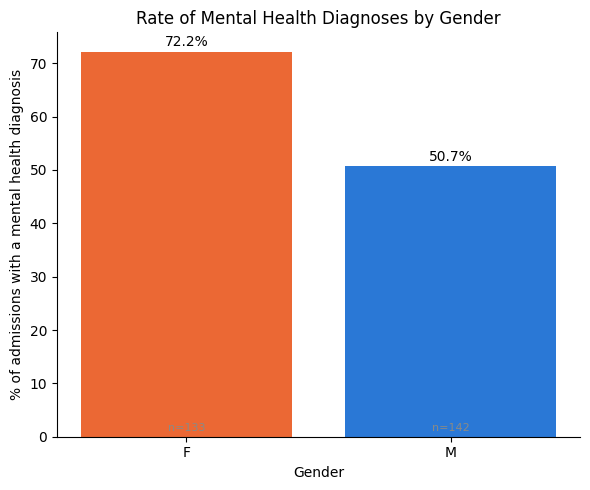

In [31]:
"""
4. Rate of mental health diagnoses by gender

Columns needed:
-----------------------
admissions.hadm_id
admissions.subject_id

patients.subject_id
patients.gender

diagnoses_icd.hadm_id
diagnoses_icd.subject_id
diagnoses_icd.icd_code
diagnoses_icd.icd_version
"""

# Flag mental health diagnosis rows (ICD version aware) 
icd9_prefix_numeric = pd.to_numeric(diagnoses_icd['icd_code'].str[:3], errors='coerce')

is_icd9_mental = (diagnoses_icd['icd_version'] == 9) & \
                   icd9_prefix_numeric.between(290, 319)

is_icd10_mental = (diagnoses_icd['icd_version'] == 10) & \
                    diagnoses_icd['icd_code'].str.startswith('F')

mental_health_dx = diagnoses_icd[is_icd9_mental | is_icd10_mental]

# Which admissions have at least one mental health diagnosis
mental_health_hadm_ids = set(mental_health_dx['hadm_id'])
admissions['has_mental_health_dx'] = admissions['hadm_id'].isin(mental_health_hadm_ids)

# Bring in gender 
admissions = admissions.merge(patients[['subject_id', 'gender']], on='subject_id', how='left')

# % of admissions with a mental health diagnosis, by gender 
summary = admissions.groupby('gender')['has_mental_health_dx'].mean() * 100
counts = admissions.groupby('gender').size()

# Visualize
plt.figure(figsize=(6, 5))
COLOR_M = '#2a78d6'
COLOR_F = '#eb6834'
bar_colors = [COLOR_F if g == 'F' else COLOR_M for g in summary.index]

bars = plt.bar(summary.index, summary.values, color=bar_colors)

for bar, pct, n in zip(bars, summary.values, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, pct + 1, f'{pct:.1f}%', ha='center')
    plt.text(bar.get_x() + bar.get_width()/2, 1, f'n={n}', ha='center',
              fontsize=8, color='#8a8a86')

plt.ylabel('% of admissions with a mental health diagnosis')
plt.xlabel('Gender')
plt.title('Rate of Mental Health Diagnoses by Gender')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

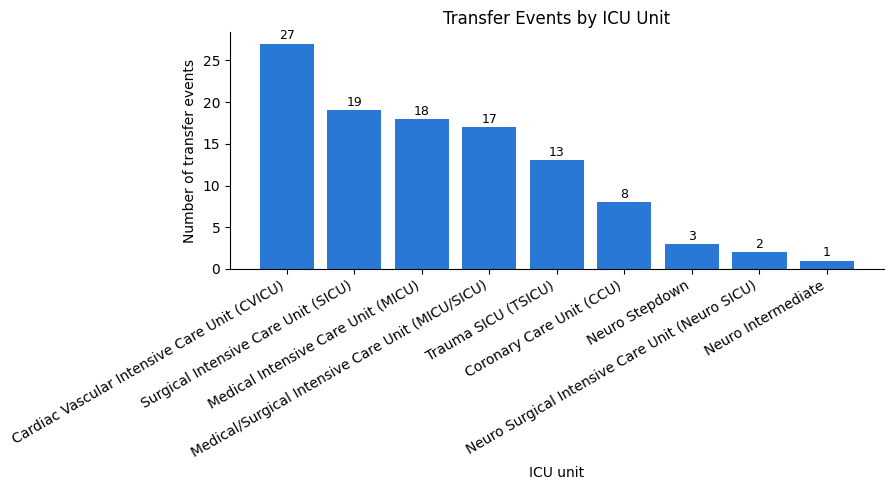

In [33]:
"""
5. Transfer rates by ICU unit

Columns needed:
-----------------------
icustays.stay_id
icustays.hadm_id
icustays.subject_id
icustays.first_careunit
icustays.last_careunit

transfers.subject_id
transfers.hadm_id
transfers.transfer_id
transfers.eventtype
transfers.careunit
transfers.intime
transfers.outtime
"""

# Build the set of valid ICU unit names 
icu_unit_names = set(icustays['first_careunit']).union(set(icustays['last_careunit']))

# Filter transfers down to actual transfer events into/out of an ICU unit 
is_transfer_event = transfers['eventtype'] == 'transfer'
is_icu_unit = transfers['careunit'].isin(icu_unit_names)

icu_transfers = transfers[is_transfer_event & is_icu_unit]

#  Count transfer events per ICU unit 
transfer_counts = (
    icu_transfers.groupby('careunit')
    .size()
    .reset_index(name='n_transfers')
    .sort_values('n_transfers', ascending=False)
)

# Visualize
plt.figure(figsize=(9, 5))
bars = plt.bar(transfer_counts['careunit'], transfer_counts['n_transfers'], color='#2a78d6')

for bar, n in zip(bars, transfer_counts['n_transfers']):
    plt.text(bar.get_x() + bar.get_width()/2, n + 0.5, str(n), ha='center', fontsize=9)

plt.ylabel('Number of transfer events')
plt.xlabel('ICU unit')
plt.title('Transfer Events by ICU Unit')
plt.xticks(rotation=30, ha='right')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('transfers_by_icu_unit.png', dpi=200)
plt.show()